**Dave**

- MSE
- RMSE
- MAE
- Summary metrics table
- Written conclusion

In [1]:
!pip install matplotlib
!pip install scikit-learn matplotlib seaborn



import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.neural_network import MLPRegressor
from preprocessing import df_basic_cleaning_and_split, array_standardise_data

X_train, X_test, y_train, y_test = df_basic_cleaning_and_split()
X_train, X_test, y_train, y_test = array_standardise_data(X_train, X_test, y_train, y_test)

y_train = y_train.flatten()
y_test = y_test.flatten()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 57.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 56.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 40.9 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 72.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [matplotlib]8 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 84.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 71.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 50.1 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [seaborn]m5/6 [seaborn]earn]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Training Model 1 for 10,000 iterations will prob take few mins(lat time it took 4 mins)
Model 1 ran Final Test MSE: 0.5111
Training Model 2 (Sklearn MLPRegressor)...
Model 2 ran Final Test MSE: 0.2979


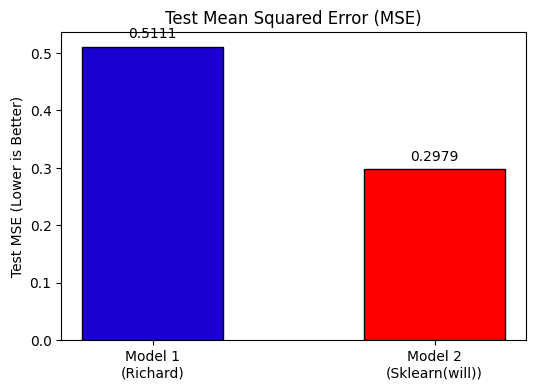

In [4]:
print("Training Model 1 for 10,000 iterations will prob take few mins(lat time it took 4 mins)")

def relu(z): return np.maximum(0, z)
def drelu(a): return (a > 0).astype(float)
def mse_loss(y_pred, y_true): return 0.5 * np.mean((y_pred - y_true)**2)

def forward(X, W1, b1, w2, b2):
    z1 = X @ W1 + b1
    a1 = relu(z1)
    z2 = a1 @ w2 + b2
    return z2.flatten(), {"a1": a1}

def backprop(X, y, W1, b1, w2, b2):
    N = X.shape[0]
    y_hat, cache = forward(X, W1, b1, w2, b2)
    a1 = cache["a1"]
    
    # Reshape y to ensure matrix math works correctly
    y = y.reshape(-1, 1)
    y_hat = y_hat.reshape(-1, 1)
    
    dL_dyhat = (y_hat - y) / N
    dL_dz2 = dL_dyhat 
    dw2 = a1.T @ dL_dz2
    db2 = np.sum(dL_dz2, axis=0)
    
    dL_da1 = dL_dz2 @ w2.T
    dL_dz1 = dL_da1 * drelu(a1)
    dW1 = X.T @ dL_dz1
    db1 = np.sum(dL_dz1, axis=0)
    
    return {"dW1": dW1, "db1": db1, "dw2": dw2, "db2": db2}

np.random.seed(2)
num_hidden = 64
W1_t = 0.5 * np.random.randn(X_train.shape[1], num_hidden)
b1_t = np.zeros(num_hidden)
w2_t = 0.5 * np.random.randn(num_hidden, 1)
b2_t = np.zeros(1)

lr = 0.001 
iters = 10000 
m1_losses = []

for t in range(iters):
    # Forward pass to get loss for the curve
    y_hat, _ = forward(X_train, W1_t, b1_t, w2_t, b2_t)
    m1_losses.append(mse_loss(y_hat, y_train))
    
    
    grads = backprop(X_train, y_train, W1_t, b1_t, w2_t, b2_t)
    W1_t -= lr * grads["dW1"]
    b1_t -= lr * grads["db1"]
    w2_t -= lr * grads["dw2"]
    b2_t -= lr * grads["db2"]

y_pred_m1, _ = forward(X_test, W1_t, b1_t, w2_t, b2_t)
m1_standard_mse = mean_squared_error(y_test, y_pred_m1)
print(f"Model 1 ran Final Test MSE: {m1_standard_mse:.4f}")

print("Training Model 2 (Sklearn MLPRegressor)...")
clf = MLPRegressor(solver='adam', alpha=1e-5, learning_rate='constant',
                   learning_rate_init=0.001, hidden_layer_sizes=(64,), 
                   random_state=1, max_iter=10000)
clf.fit(X_train, y_train)

y_pred_m2 = clf.predict(X_test)
m2_standard_mse = mean_squared_error(y_test, y_pred_m2)
print(f"Model 2 ran Final Test MSE: {m2_standard_mse:.4f}")

fig, axs = plt.subplots(1, 1, figsize=(6, 4))  # Define axs before using it

bars = axs.bar(['Model 1\n(Richard)', 'Model 2\n(Sklearn(will))'], 
               [m1_standard_mse, m2_standard_mse], 
               color=["#1C00D1", "#FF0000"], edgecolor='black', width=0.5)
axs.set_title('Test Mean Squared Error (MSE)', fontsize=12)
axs.set_ylabel('Test MSE (Lower is Better)')
for bar in bars:
    axs.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{bar.get_height():.4f}', ha='center', va='bottom')

plt.show()